# 03 · Plan Explanation

> Part of the **ICAPS 2026 Planning Ontology Tutorial**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai4society/ICAPS26-planning-ontology-tutorial/blob/main/notebooks/03_plan_explanation.ipynb)

A plan is a sequence of actions, but a user wants to know **why** those actions, in
that order. When the knowledge graph stores an explanation for the plan and for each
action, you can read them straight back out and assemble a narrative a person can
follow.

In this notebook you:

- **Read** the plan-level explanation, its cost, and its planner
- **List** the per-action explanations
- **Assemble** an ordered, step-by-step narrative of the plan

> **Tip.** The **Core** path reads the stored explanations as written. **Go deeper**
> grounds each template on the step's actual arguments.

---


## Setup

Run this first. In **Colab** it installs the dependencies and fetches the tutorial
data. **Locally** it uses your `requirements.txt` environment.


In [ ]:
# In Colab this installs dependencies and fetches the tutorial data.
# Locally it assumes you installed requirements.txt.
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess

    subprocess.run(["pip", "install", "-q", "rdflib", "pandas"], check=True)
    subprocess.run(
        [
            "git",
            "clone",
            "-q",
            "https://github.com/ai4society/ICAPS26-planning-ontology-tutorial.git",
        ],
        check=False,
    )
    DATA = Path("ICAPS26-planning-ontology-tutorial/data")
else:
    DATA = Path("..") / "data"

print("data directory:", DATA.resolve())

data directory: /Users/nitingupta/usc/ai4s/conferences/icaps26/tutorial/planning-ontology-tutorial/data


---

## 1. Load the knowledge graph

The blocksworld KG holds a six-step plan for `problem_3_1`, with a plan-level
explanation, a per-action explanation on every action, and ordered steps. The steps
use a small tutorial extension (`tut:`) that numbers them and links each one to the
action it grounds.


In [2]:
from rdflib import Graph, Namespace, Literal, RDF, RDFS

PO = Namespace("https://purl.org/ai4s/ontology/planning#")
TUT = Namespace("https://w3id.org/planning-ontology-tutorial#")
PREFIX = (
    "PREFIX po: <https://purl.org/ai4s/ontology/planning#> "
    "PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> "
    "PREFIX tut: <https://w3id.org/planning-ontology-tutorial#> "
)

kg = Graph()
kg.parse(str(DATA / "kgs" / "blocksworld_tutorial.ttl"), format="turtle")
print(f"loaded blocksworld KG: {len(kg)} triples")

loaded blocksworld KG: 106 triples


---

## 2. The plan-level explanation (Core)

Start with the big picture. One query returns the plan's cost, the planner that
generated it, and the stored `hasPlanExplanation` text.


In [ ]:
plan_query = (
    PREFIX
    + """
SELECT ?cost ?planner ?explanation WHERE {
  po:problem_3_1 po:hasPlan ?plan .
  ?plan po:hasPlanCost ?cost .
  ?plan po:isGeneratedBy ?gen .
  ?gen rdfs:label ?planner .
  ?plan po:hasPlanExplanation ?explanation .
}
"""
)

row = list(kg.query(plan_query))[0]
print(f"planner : {row.planner}")
print(f"cost    : {int(row.cost)} steps")
print(f"why     : {row.explanation}")

planner : Fast Downward
cost    : 6 steps
why     : To build the tower b1 < b2 < b3, the planner first clears b1 by unstacking b3, then stacks b2 on b1 and finally b3 on b2.


---

## 3. The per-action explanations (Core)

Every action carries a `hasActionExplanation`: a short, reusable description of what
the action does. These read as templates, with variables such as `?x` and `?y`
standing in for the blocks.


In [ ]:
import pandas as pd

action_query = (
    PREFIX
    + """
SELECT ?action ?explanation WHERE {
  ?a rdfs:label ?action .
  ?a po:hasActionExplanation ?explanation .
} ORDER BY ?action
"""
)

rows = [(str(r.action), str(r.explanation)) for r in kg.query(action_query)]
pd.DataFrame(rows, columns=["action", "explanation"])

,action,explanation
0,pick-up,Pick up a clear block from the table; afterwar...
1,put-down,Put the held block onto the table; the hand be...
2,stack,Place the held block ?x onto another clear blo...
3,unstack,Remove a clear block ?x from the block ?y bene...


---

## 4. Assemble the step-by-step narrative (Core)

Now join the two layers. The ordered steps come from the `tut:` extension, and each
step links to its action's explanation. Sorting by `tut:stepNumber` gives the plan
in execution order.


In [ ]:
narrative_query = (
    PREFIX
    + """
SELECT ?n ?grounded ?explanation WHERE {
  ?step tut:stepOf po:plan_3_1 ;
        tut:stepNumber ?n ;
        rdfs:label ?grounded ;
        tut:groundsAction ?act .
  ?act po:hasActionExplanation ?explanation .
} ORDER BY ?n
"""
)

print("Plan for problem_3_1:\n")
for r in kg.query(narrative_query):
    print(f"  Step {int(r.n)}: {r.grounded}")
    print(f"          {r.explanation}\n")

Plan for problem_3_1:

  Step 1: unstack b3 b1
          Remove a clear block ?x from the block ?y beneath it; the hand then holds it.

  Step 2: put-down b3
          Put the held block onto the table; the hand becomes empty.

  Step 3: pick-up b2
          Pick up a clear block from the table; afterwards the hand is holding it.

  Step 4: stack b2 b1
          Place the held block ?x onto another clear block ?y.

  Step 5: pick-up b3
          Pick up a clear block from the table; afterwards the hand is holding it.

  Step 6: stack b3 b2
          Place the held block ?x onto another clear block ?y.



---

## Go deeper: ground the templates on real arguments

The Core narrative shows the action templates verbatim, so `?x` and `?y` still
appear. To read as plain English, each template needs the step's actual blocks. The
step label (`stack b2 b1`) lists the arguments in order, and the action's parameters
(`?x - block`, `?y - block`) list the variables in order. Zip them together and
substitute.


In [ ]:
def parameters_in_order(graph, action_iri):
    q = (
        PREFIX
        + """
    SELECT ?plabel WHERE { ?act po:hasParameter ?p . ?p rdfs:label ?plabel }
    ORDER BY ?p
    """
    )
    labels = [str(r.plabel) for r in graph.query(q, initBindings={"act": action_iri})]
    return [lbl.split()[0] for lbl in labels]  # "?x - block" -> "?x"


def grounded_narrative(graph):
    q = (
        PREFIX
        + """
    SELECT ?n ?grounded ?act ?explanation WHERE {
      ?step tut:stepOf po:plan_3_1 ;
            tut:stepNumber ?n ;
            rdfs:label ?grounded ;
            tut:groundsAction ?act .
      ?act po:hasActionExplanation ?explanation .
    } ORDER BY ?n
    """
    )
    lines = []
    for r in graph.query(q):
        variables = parameters_in_order(graph, r.act)
        arguments = str(r.grounded).split()[1:]  # drop the action name
        text = str(r.explanation)
        for var, arg in zip(variables, arguments):
            text = text.replace(var, arg)
        lines.append((int(r.n), str(r.grounded), text))
    return lines


for n, grounded, text in grounded_narrative(kg):
    print(f"  {n}. {grounded}: {text}")

  1. unstack b3 b1: Remove a clear block b3 from the block b1 beneath it; the hand then holds it.
  2. put-down b3: Put the held block onto the table; the hand becomes empty.
  3. pick-up b2: Pick up a clear block from the table; afterwards the hand is holding it.
  4. stack b2 b1: Place the held block b2 onto another clear block b1.
  5. pick-up b3: Pick up a clear block from the table; afterwards the hand is holding it.
  6. stack b3 b2: Place the held block b3 onto another clear block b2.


---

## Go deeper: see the plan run

Words describe the plan; a picture shows it. This **replays** the six steps over
the blocksworld state and draws the **towers** after each action, so you watch
`b3` come off `b1`, then the tower build back up as `b1 < b2 < b3`.


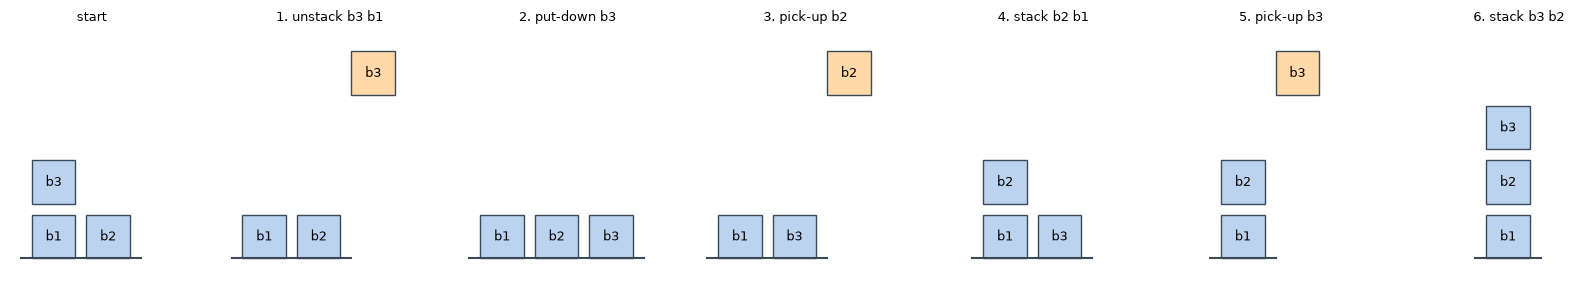

In [ ]:
# Go deeper. Needs matplotlib (the viz extra).
import sys

if IN_COLAB:
    import subprocess

    subprocess.run(["pip", "install", "-q", "matplotlib"], check=True)
    sys.path.insert(0, "ICAPS26-planning-ontology-tutorial/notebooks")
else:
    sys.path.insert(0, ".")

steps = [
    str(r.grounded)
    for r in kg.query(
        PREFIX
        + """
    SELECT ?n ?grounded WHERE {
      ?step tut:stepOf po:plan_3_1 ; tut:stepNumber ?n ; rdfs:label ?grounded .
    } ORDER BY ?n"""
    )
]

try:
    import viz

    viz.draw_plan_states(DATA, steps)
except ImportError:
    print("Install the viz extra to draw the plan: pip install matplotlib")

---

## Go deeper: give the KG the formal action model

The stored explanations read well but are **prose**. The PDDL holds the formal
**preconditions and effects**. This parses them and writes them back into the KG
under the `tut:` extension, the same write-back pattern notebook 02 used for a
fresh plan. Now the graph carries the **action semantics**, not only the narrative.


In [ ]:
import explain

domain_text = (DATA / "domains" / "blocksworld" / "domain.pddl").read_text()
problem_text = (DATA / "domains" / "blocksworld" / "problem.pddl").read_text()
schemas = explain.parse_action_schemas(domain_text)

added = explain.schemas_to_triples(kg, schemas, PO, TUT)
print(f"added {added} structured precondition/effect triples")

# read the structured effects of stack straight back out
for r in kg.query(
    PREFIX
    + """
    SELECT ?label WHERE { po:stack tut:hasAddEffect ?e . ?e rdfs:label ?label }"""
):
    print("  stack adds:", r.label)

added 54 structured precondition/effect triples
  stack adds: clear(?x)
  stack adds: handempty()
  stack adds: on(?x, ?y)


---

## Go deeper: why this order

A step has to wait for what it needs. With the formal model in hand, you can
trace each step's preconditions back to the earlier step that produced them.
That is the **causal backbone** of the plan, and it explains the ordering instead of narrating it.


In [9]:
init = explain.parse_init(problem_text)
links = explain.causal_links(init, steps, schemas)

for entry in links:
    print(f"Step {entry['step']}: {entry['action']}")
    if not entry["links"]:
        print("    (preconditions all hold in the initial state)")
    for producer, pred in entry["links"]:
        atom = explain.atom_label(pred)
        if producer == 0:
            print(f"    needs {atom}, true from the start")
        else:
            cause = links[producer - 1]["action"]
            print(f"    needs {atom}, produced by step {producer} ({cause})")

Step 1: unstack b3 b1
    needs on(b3, b1), true from the start
    needs clear(b3), true from the start
    needs handempty(), true from the start
Step 2: put-down b3
    needs holding(b3), produced by step 1 (unstack b3 b1)
Step 3: pick-up b2
    needs clear(b2), true from the start
    needs ontable(b2), true from the start
    needs handempty(), produced by step 2 (put-down b3)
Step 4: stack b2 b1
    needs holding(b2), produced by step 3 (pick-up b2)
    needs clear(b1), produced by step 1 (unstack b3 b1)
Step 5: pick-up b3
    needs clear(b3), produced by step 2 (put-down b3)
    needs ontable(b3), produced by step 2 (put-down b3)
    needs handempty(), produced by step 4 (stack b2 b1)
Step 6: stack b3 b2
    needs holding(b3), produced by step 5 (pick-up b3)
    needs clear(b2), produced by step 4 (stack b2 b1)


> **Note.** The grounded narrative is template-based, so it stays faithful to the
> KG. The same step records feed a natural-language generator or a large language
> model when you want richer prose.


---

## Recap and next

You read a plan's explanation, listed its action templates, and grounded them into
a walk-through. In the Go-deeper cells you drew the plan as block towers and traced
the causal links that fix its order.

| Notebook                             | Focus                                                                                   |
| ------------------------------------ | --------------------------------------------------------------------------------------- |
| **00 · Quickstart**                  | Ask both questions through one-line helpers, then see the plan                          |
| **01 · Ontology and KG foundations** | Load the ontology, build a KG from PDDL, query and reason over it                       |
| **02 · Planner selection**           | Rank planners for a domain, then chart the field across IPC-2018                        |
| **03 · Plan explanation**            | Read a plan's story, watch it run, and trace why its steps are ordered _(you are here)_ |


> **Recommended next:** **00 · Quickstart**, the one-line view of everything you
> just built.
